In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [14]:
df = pd.read_csv("freelancers_dev.csv")

df.head()

,freelancer_id,proyectos_completados,ingresos_totales,tarifa_hora_promedio,anios_experiencia,tiempo_respuesta_horas,tasa_finalizacion,calificacion_promedio,categoria_principal,clientes_recurrentes,horas_trabajadas_mes
0,FL0001,42,73500.53,107.08,14.5,4.9,90.1,4.26,Desarrollo de Software,8,69.3
1,FL0002,37,4601.49,20.75,3.4,7.3,68.1,4.57,Diseño Gráfico,10,85.5
2,FL0003,9,2441.74,16.61,1.8,43.2,54.9,3.0,Diseño Gráfico,2,27.9
3,FL0004,47,9472.69,22.31,2.6,7.1,79.9,4.53,Diseño Gráfico,11,73.0
4,FL0005,19,30214.17,61.33,5.0,6.8,87.1,4.75,Marketing Digital,13,56.6


In [15]:
df.dtypes
for col in df.columns:
    print(col, df[col].dtype)

freelancer_id object
proyectos_completados object
ingresos_totales float64
tarifa_hora_promedio object
anios_experiencia float64
tiempo_respuesta_horas float64
tasa_finalizacion float64
calificacion_promedio object
categoria_principal object
clientes_recurrentes int64
horas_trabajadas_mes float64


In [3]:
print("Filas:",df.shape[0])

print("Columnas:",df.shape[1])

Filas: 1590
Columnas: 11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   freelancer_id           1590 non-null   object 
 1   proyectos_completados   1590 non-null   object 
 2   ingresos_totales        1590 non-null   float64
 3   tarifa_hora_promedio    1551 non-null   object 
 4   anios_experiencia       1558 non-null   float64
 5   tiempo_respuesta_horas  1561 non-null   float64
 6   tasa_finalizacion       1537 non-null   float64
 7   calificacion_promedio   1550 non-null   object 
 8   categoria_principal     1590 non-null   object 
 9   clientes_recurrentes    1590 non-null   int64  
 10  horas_trabajadas_mes    1590 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 136.8+ KB


In [5]:
df.describe()

,ingresos_totales,anios_experiencia,tiempo_respuesta_horas,tasa_finalizacion,clientes_recurrentes,horas_trabajadas_mes
count,1590.000000,1558.000000,1561.000000,1537.000000,1590.000000,1590.000000
mean,21139.412704,5.480167,9.954644,79.509759,15.286792,89.071321
std,19798.268158,6.551717,10.550347,18.893544,12.847638,42.641386
min,0.000000,0.000000,0.100000,-25.400000,0.000000,0.000000
25%,5135.422500,2.100000,3.200000,72.400000,6.000000,55.825000
50%,11118.160000,4.200000,6.100000,85.500000,12.000000,83.050000
75%,35103.412500,7.500000,10.000000,92.900000,20.000000,123.875000
max,87517.590000,64.100000,54.600000,128.900000,63.000000,200.400000


In [6]:
df.isnull().sum()

freelancer_id              0
proyectos_completados      0
ingresos_totales           0
tarifa_hora_promedio      39
anios_experiencia         32
tiempo_respuesta_horas    29
tasa_finalizacion         53
calificacion_promedio     40
categoria_principal        0
clientes_recurrentes       0
horas_trabajadas_mes       0
dtype: int64

In [7]:
(df.isnull().sum()/len(df))*100

freelancer_id             0.000000
proyectos_completados     0.000000
ingresos_totales          0.000000
tarifa_hora_promedio      2.452830
anios_experiencia         2.012579
tiempo_respuesta_horas    1.823899
tasa_finalizacion         3.333333
calificacion_promedio     2.515723
categoria_principal       0.000000
clientes_recurrentes      0.000000
horas_trabajadas_mes      0.000000
dtype: float64

In [8]:
df.duplicated().sum()

90

In [9]:
df.dtypes

freelancer_id              object
proyectos_completados      object
ingresos_totales          float64
tarifa_hora_promedio       object
anios_experiencia         float64
tiempo_respuesta_horas    float64
tasa_finalizacion         float64
calificacion_promedio      object
categoria_principal        object
clientes_recurrentes        int64
horas_trabajadas_mes      float64
dtype: object

In [16]:
df["proyectos_completados"].unique()

array(['42', '37', '9', '47', '19', '61', '59', '4', '36', '30', '149',
       '28', '18', '10', '7', '45', '57', '38', '79', '5', '6', '16',
       '34', '55', '110', '21', '40', '27', '98', '24', '8', '23', '32',
       '20', '35', '48', '145', '89', '63', '12', '14', '82', '148', '54',
       '13', '112', '0', '101', '153', '15', '91', '22', '65', '26',
       'sin dato', '90', '113', '127', '51', '109', '97', '147', '120',
       '25', '31', '142', '29', '64', '105', '17', '46', '41', '52',
       '118', '78', '85', '43', 'nd', '11', '3', '157', '49', '100', '44',
       '-18', '33', '123', '81', '94', '140', '155', '124', '103', '136',
       '39', '77', '-3', '2', '75', '83', '80', '50', '74', '104', '143',
       '99', '68', '141', '86', '135', '133', '129', '121', '71', '67',
       '-13', '116', '93', '107', '53', '130', '131', '73', '125', '66',
       '60', '102', '84', '58', '-2', '159', '117', '1', '162', '126',
       '-17', '152', '76', '114', '201', '161', '?', '69', '1

In [17]:
df["tarifa_hora_promedio"].unique()

array(['107.08', '20.75', '16.61', ..., '26.69', '66.58', '55.79'],
      dtype=object)

In [18]:
df["calificacion_promedio"].unique()

array(['4.26', '4.57', '3.0', '4.53', '4.75', '3.94', '4.3', '4.66',
       '4.71', '4.73', '4.1', '4.58', '3.34', '2.87', '4.23', '4.48',
       '4.92', '4.72', '3.39', '3.1', 'sin dato', '4.5', '4.06', '4.51',
       '4.22', '4.55', '4.42', '4.47', '4.85', '4.36', '4.28', '2.16',
       '4.61', '4.63', '4.96', '3.68', '4.77', '4.09', '4.08', '4.86',
       '4.54', '4.03', '4.41', '4.6', '2.22', '2.78', '3.37', '4.67',
       '4.76', '4.45', '3.71', '3.16', '1.6', '4.29', '2.68', '4.69',
       '2.84', '3.18', '3.22', '4.7', '4.59', '4.14', '3.52', '4.07',
       '4.27', '2.64', '3.84', '4.93', '4.83', '2.82', '3.64', '5.0',
       '4.88', '2.89', '3.44', '3.96', '2.51', '4.18', '3.35', '3.05',
       '4.56', '4.33', '3.74', '3.59', '4.46', '4.78', '3.13', '3.54',
       '4.74', '3.41', '3.8', '3.65', '2.81', '4.94', '4.65', '4.37',
       '4.8', nan, '4.84', '2.79', '4.2', '2.07', '5.6', '2.97', '3.14',
       '6.5', '3.95', '3.31', '3.77', '3.98', '3.91', '4.0', '1.94',
       '4.79

In [20]:
columnas = [
    "proyectos_completados",
    "tarifa_hora_promedio",
    "calificacion_promedio"
]

for col in columnas:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [21]:
df.dtypes

freelancer_id              object
proyectos_completados     float64
ingresos_totales          float64
tarifa_hora_promedio      float64
anios_experiencia         float64
tiempo_respuesta_horas    float64
tasa_finalizacion         float64
calificacion_promedio     float64
categoria_principal        object
clientes_recurrentes        int64
horas_trabajadas_mes      float64
dtype: object

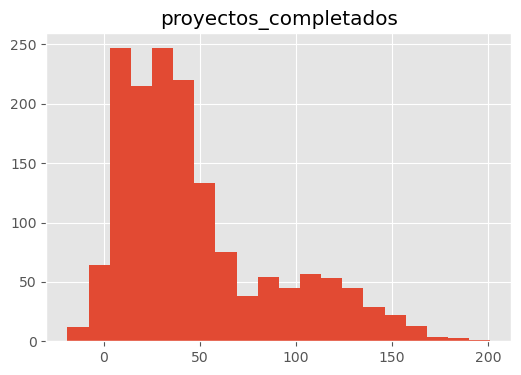

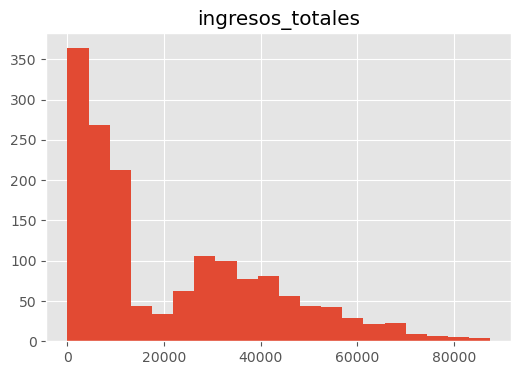

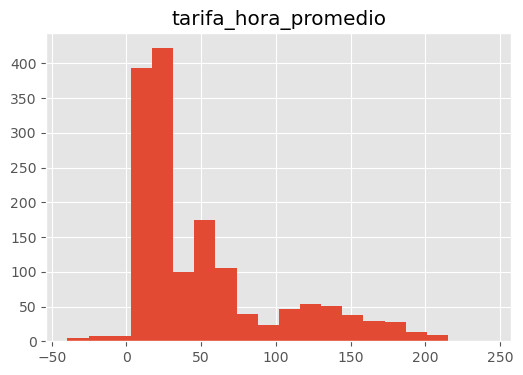

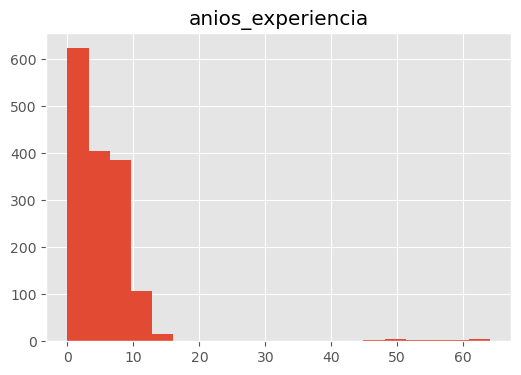

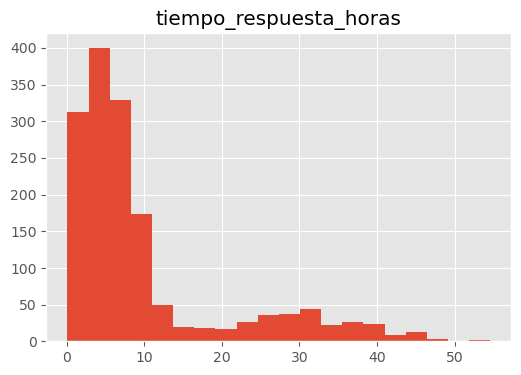

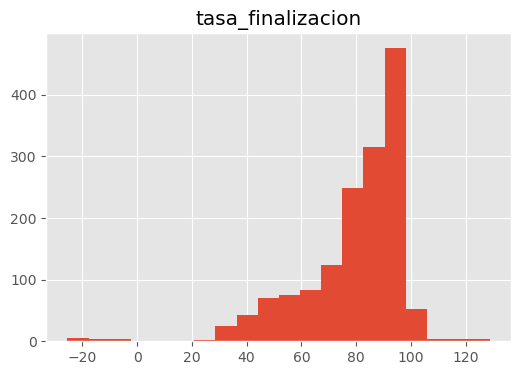

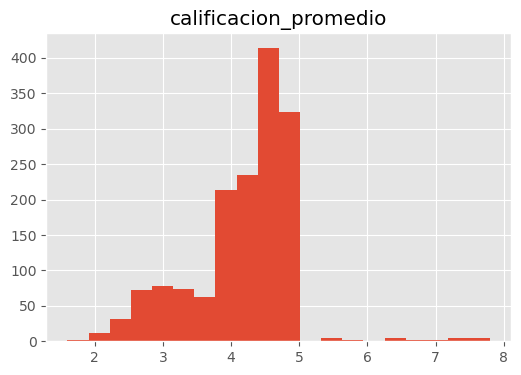

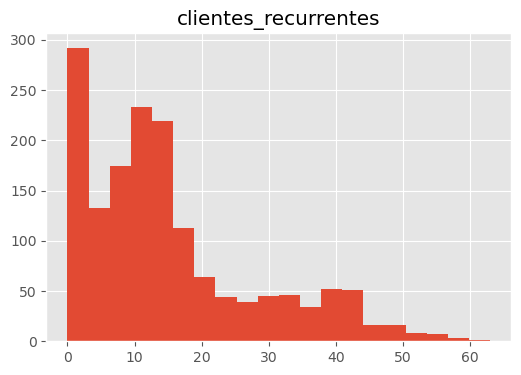

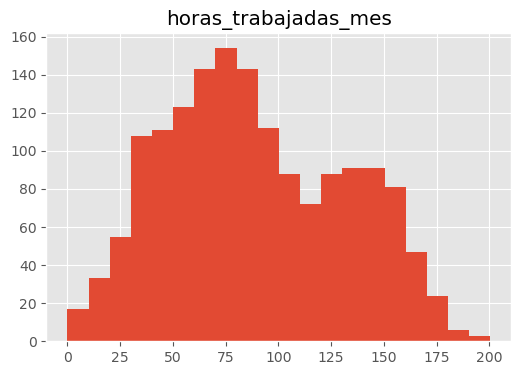

In [22]:
numericas = [
            "proyectos_completados",
            "ingresos_totales",
            "tarifa_hora_promedio",
            "anios_experiencia",
            "tiempo_respuesta_horas",
            "tasa_finalizacion",
            "calificacion_promedio",
            "clientes_recurrentes",
            "horas_trabajadas_mes"
            ]
for col in numericas:
    plt.figure(figsize=(6,4))
    plt.hist(df[col],bins=20)
    plt.title(col)
    plt.show()
    

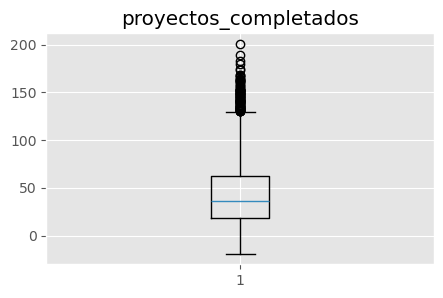

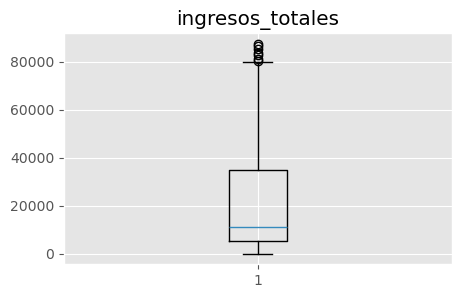

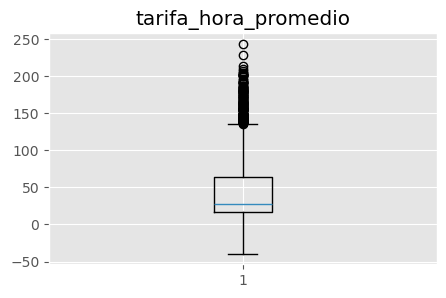

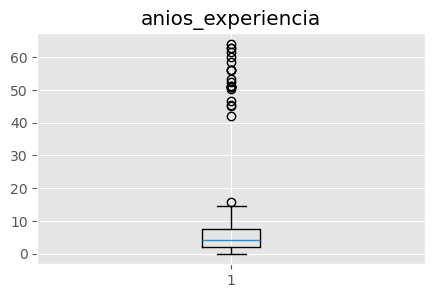

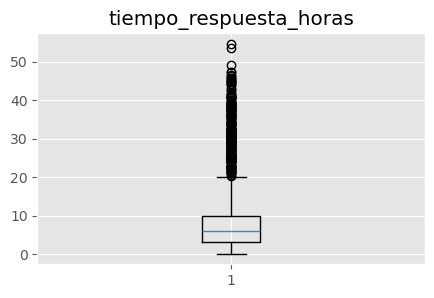

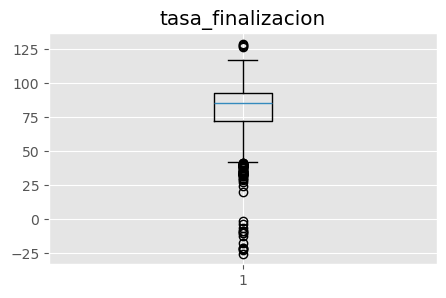

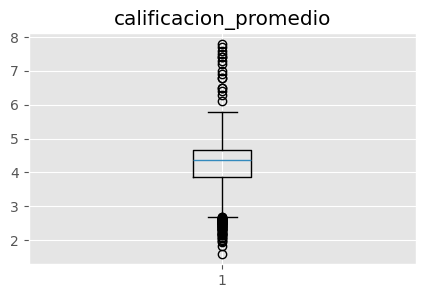

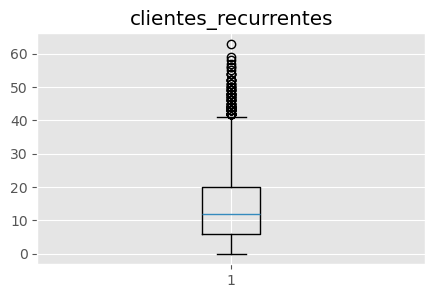

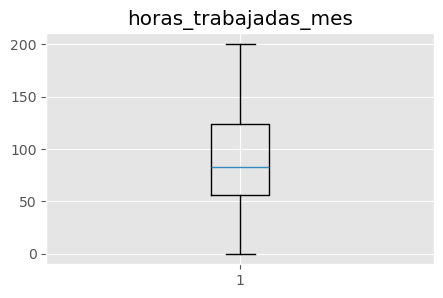

In [23]:
for col in numericas:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [24]:
df[numericas].skew()

proyectos_completados     1.111398
ingresos_totales          0.897336
tarifa_hora_promedio      1.383146
anios_experiencia         5.654916
tiempo_respuesta_horas    1.789893
tasa_finalizacion        -1.720288
calificacion_promedio    -0.281823
clientes_recurrentes      1.115363
horas_trabajadas_mes      0.235224
dtype: float64

In [25]:
for col in numericas:
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3-Q1
    LI = Q1-1.5*IQR
    LS = Q3+1.5*IQR
    total=((df[col]<LI)|(df[col]>LS)).sum()
    print(col,total)

proyectos_completados 86
ingresos_totales 7
tarifa_hora_promedio 153
anios_experiencia 22
tiempo_respuesta_horas 252
tasa_finalizacion 69
calificacion_promedio 89
clientes_recurrentes 87
horas_trabajadas_mes 0


In [26]:
corr=df[numericas].corr()
corr

,proyectos_completados,ingresos_totales,tarifa_hora_promedio,anios_experiencia,tiempo_respuesta_horas,tasa_finalizacion,calificacion_promedio,clientes_recurrentes,horas_trabajadas_mes
proyectos_completados,1.000000,0.268663,0.028421,0.194864,-0.542135,0.506185,0.489786,0.774549,0.773749
ingresos_totales,0.268663,1.000000,0.811368,0.368652,-0.520016,0.564696,0.598721,0.406162,0.195464
tarifa_hora_promedio,0.028421,0.811368,1.000000,0.345435,-0.405229,0.460606,0.487488,0.198964,-0.024340
anios_experiencia,0.194864,0.368652,0.345435,1.000000,-0.277403,0.299317,0.295790,0.245689,0.157204
tiempo_respuesta_horas,-0.542135,-0.520016,-0.405229,-0.277403,1.000000,-0.690728,-0.704533,-0.570085,-0.589146
tasa_finalizacion,0.506185,0.564696,0.460606,0.299317,-0.690728,1.000000,0.646356,0.551985,0.498297
calificacion_promedio,0.489786,0.598721,0.487488,0.295790,-0.704533,0.646356,1.000000,0.558110,0.487012
clientes_recurrentes,0.774549,0.406162,0.198964,0.245689,-0.570085,0.551985,0.558110,1.000000,0.731055
horas_trabajadas_mes,0.773749,0.195464,-0.024340,0.157204,-0.589146,0.498297,0.487012,0.731055,1.000000


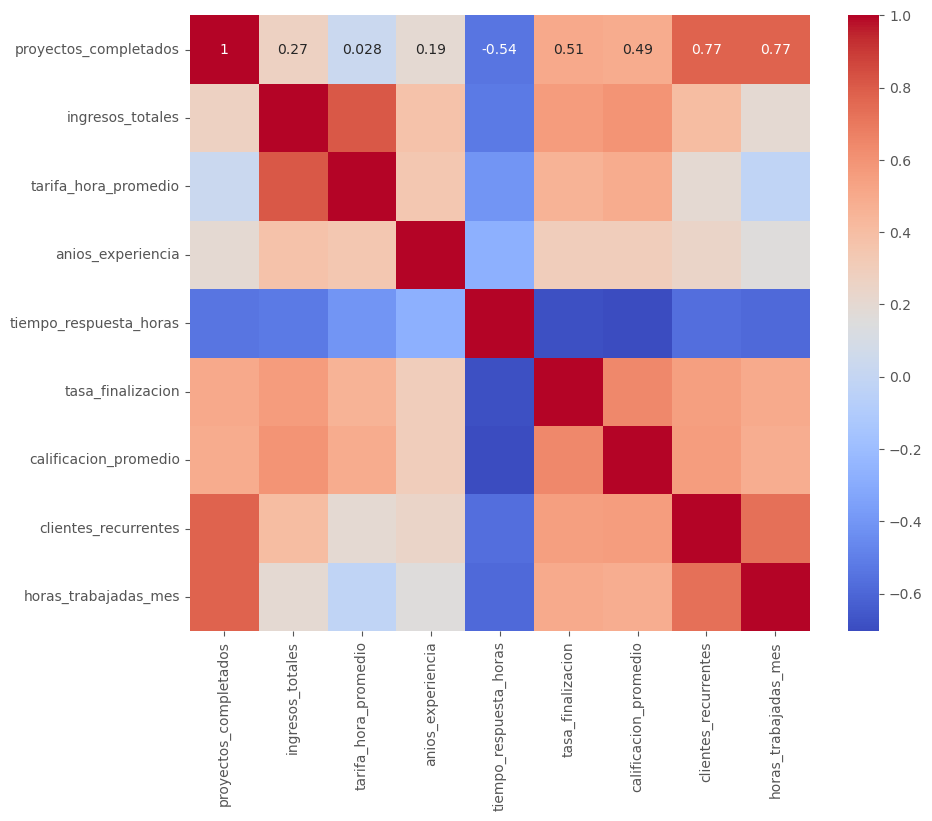

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [28]:
df["categoria_principal"].value_counts()

categoria_principal
Desarrollo de Software            500
Diseño Gráfico                    334
Marketing Digital                 272
Redacción y Traducción            242
Soporte Administrativo Virtual    242
Name: count, dtype: int64

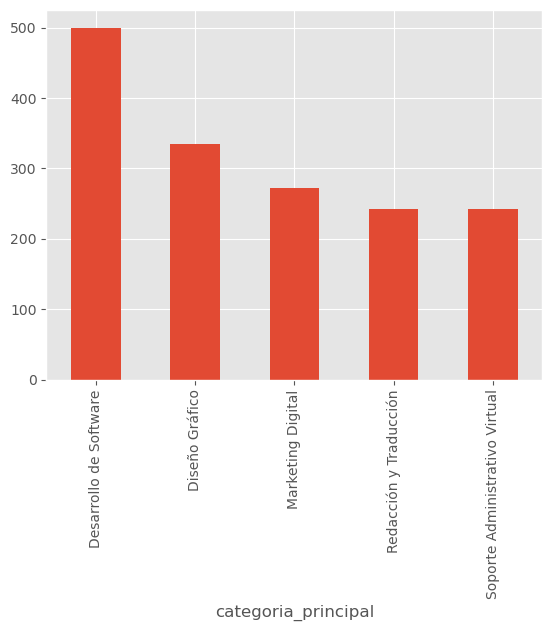

In [29]:
df["categoria_principal"].value_counts().plot(kind="bar")
plt.show()

In [31]:
(df["ingresos_totales"]<0).sum()

0

In [32]:
(df["anios_experiencia"]<0).sum()

0

In [33]:
((df["tasa_finalizacion"]<0)|(df["tasa_finalizacion"]>100)).sum()

27

In [34]:
((df["calificacion_promedio"]<0)|(df["calificacion_promedio"]>5)).sum()

23